In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix




from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc


from sklearn.metrics import accuracy_score

import xgboost as xgb
from sklearn.model_selection import GridSearchCV



## Step 1 — Load and Inspect the Raw Data

In [38]:
df = pd.read_csv("data/atp_tennis.csv", low_memory=False)

In [39]:
df["Odd_2"].isnull().sum()

np.int64(0)

In [40]:
df.head(5).dtypes


Tournament        str
Date              str
Series            str
Court             str
Surface           str
Round             str
Best of         int64
Player_1          str
Player_2          str
Winner            str
Rank_1          int64
Rank_2          int64
Pts_1           int64
Pts_2           int64
Odd_1         float64
Odd_2             str
Score             str
dtype: object

## Step 2 — Filter to Wimbledon Only

In [41]:
df = df[df["Tournament"] == "Wimbledon"]
df.shape

(3061, 17)

## Step 3 — Exploratory Data Analysis

In [42]:
rounds = df["Round"].value_counts().sort_index()
print(rounds)


Round
1st Round        1539
2nd Round         769
3rd Round         390
4th Round         192
Quarterfinals      98
Semifinals         48
The Final          25
Name: count, dtype: int64


<BarContainer object of 7 artists>

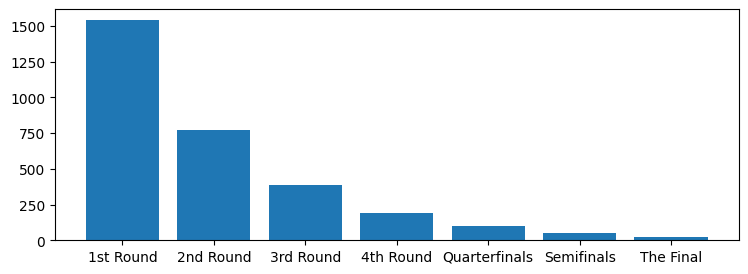

In [43]:
round_names = ["1st Round","2nd Round","3rd Round","4th Round","Quarterfinals","Semifinals","The Final"]
values = [1, 10, 100]

plt.figure(figsize=(30, 3))

plt.subplot(131)
plt.bar(round_names, rounds)


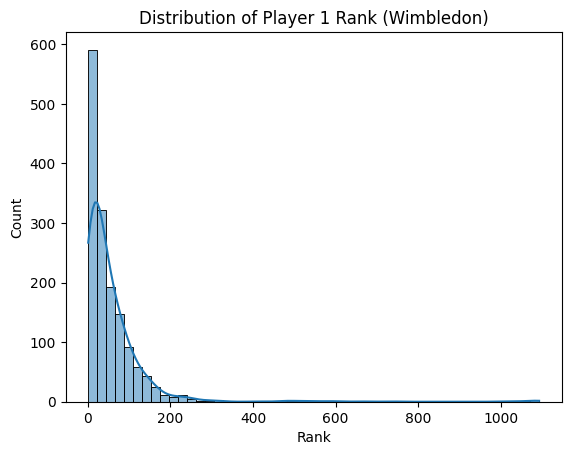

In [44]:
winners = df[df["Winner"] == df["Player_1"]]
sns.histplot(winners["Rank_1"], bins=50, kde=True)
plt.title("Distribution of Player 1 Rank (Wimbledon)")
plt.xlabel("Rank")
plt.ylabel("Count")
plt.show()



## Step 4 — Clean the Data

In [45]:
df["Odd_1"] = df["Odd_1"].replace(-1.00,np.nan)
df["Odd_2"] = df["Odd_2"].replace(-1.00,np.nan)
df["Pts_1"] = df["Pts_1"].replace(-1.00,np.nan)
df["Pts_2"] = df["Pts_2"].replace(-1.00,np.nan)

print("Odd_2 dtype before:", df["Odd_2"].dtype)
df["Odd_2"] = pd.to_numeric(df["Odd_2"], errors='coerce')
print("Odd_2 dtype after:", df["Odd_2"].dtype)




Odd_2 dtype before: str
Odd_2 dtype after: float64


In [46]:
df["Date"] = pd.to_datetime(df["Date"])
print(df["Date"])

1527    2000-06-26
1528    2000-06-26
1529    2000-06-26
1530    2000-06-26
1531    2000-06-26
           ...    
65699   2025-07-09
65700   2025-07-09
65701   2025-07-11
65702   2025-07-11
65703   2025-07-13
Name: Date, Length: 3061, dtype: datetime64[us]


In [47]:
print(df.shape)
print(df[["Rank_1", "Rank_2"]].isnull().sum())

(3061, 17)
Rank_1    0
Rank_2    0
dtype: int64


## Step 5 — Feature Engineering

In [48]:
df["Pts_1"] = df["Pts_1"].replace(np.nan,0)
df["Pts_2"] = df["Pts_2"].replace(np.nan,0)


round_map = {
    "1st Round"     : 1,
    "2nd Round"     : 2,
    "3rd Round"     : 3,
    "4th Round"     : 4,
    "Quarterfinals" : 5,
    "Semifinals"    : 6,
    "The Final"     : 7
}

df["rank_diff"] = df["Rank_1"] - df["Rank_2"]
df["pts_diff"] = df["Pts_1"] - df["Pts_2"]
df["round_encoded"] = df["Round"].map(round_map)
df["target"] = (df["Winner"] == df["Player_1"]).astype(int)

df[["rank_diff", "pts_diff", "round_encoded", "target"]].describe()

,rank_diff,pts_diff,round_encoded,target
count,3061.000000,3061.000000,3061.000000,3061.000000
mean,1.056191,16.324404,1.949690,0.500163
std,132.932265,2705.543989,1.273697,0.500082
min,-1060.000000,-16641.000000,1.000000,0.000000
25%,-50.000000,-495.000000,1.000000,0.000000
50%,-1.000000,0.000000,1.000000,1.000000
75%,50.000000,473.000000,2.000000,1.000000
max,1038.000000,16070.000000,7.000000,1.000000


## Step 6 — Train / Test Split

In [49]:
df_sorted = df.sort_values("Date")


cutoff = pd.Timestamp("2018-01-01")
train = df_sorted[df_sorted["Date"] < cutoff]
test = df_sorted[df_sorted["Date"] >= cutoff]

features = ["rank_diff","pts_diff","round_encoded"]
X_train = train[features]
y_train = train["target"]

X_test = test[features]
y_test = test["target"]


print("X_train shape: ",X_train.shape)
print("X_test shape: ", X_test.shape)
print("Train date range:", train["Date"].min().date(),"->", train["Date"].max().date())
print("Test date range: ", test["Date"].min().date(),"->",test["Date"].max().date())



X_train shape:  (2197, 3)
X_test shape:  (864, 3)
Train date range: 2000-06-26 -> 2017-07-16
Test date range:  2018-07-02 -> 2025-07-13


## Step 7 — Naive Baseline

In [50]:
baseline_pred = (X_test["rank_diff"] < 0 ).astype(int)
print("Baseline accuracy:", round(accuracy_score(y_test,baseline_pred),3))

Baseline accuracy: 0.688


## Step 8 — Train Three Models

In [51]:
rf = RandomForestClassifier()

rf.fit(X_train,y_train)



print("rank_diff      ", rf.feature_importances_[0])
print("pts_diff       ", rf.feature_importances_[1])
print("round_encoded  ",rf.feature_importances_[2])



rank_diff       0.5593277158977878
pts_diff        0.40627190254504214
round_encoded   0.03440038155717015


## Step 9 — Evaluate All Three Models

In [52]:
logistic_model = LogisticRegression(random_state=42)
logistic_model.fit(X_train, y_train)

random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model.fit(X_train, y_train)

xgb_model = xgb.XGBClassifier(random_state=42, eval_metric="logloss")
xgb_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict_proba(X_test)[:, 1]
y_pred_rf       = random_forest_model.predict_proba(X_test)[:, 1]
y_pred_xgboost  = xgb_model.predict_proba(X_test)[:, 1]

test_df = pd.DataFrame({
    'True': y_test,
    'Logistic': y_pred_logistic,
    'RandomForest': y_pred_rf,
    'XGBoost': y_pred_xgboost,
})

for name in ['Logistic', 'RandomForest', 'XGBoost']:
    probs = test_df[name]
    preds = (probs >= 0.5).astype(int)

    accuracy = accuracy_score(test_df['True'], preds)
    roc_auc = roc_auc_score(test_df['True'], probs)
    cm = confusion_matrix(test_df['True'], preds)
    tn, fp, fn, tp = cm.ravel()

    print(f"{name}: Accuracy={accuracy:.3f}  ROC-AUC={roc_auc:.3f}")
    print(f"[[{tn} {fp}]\n [{fn} {tp}]]")


Logistic: Accuracy=0.689  ROC-AUC=0.764
[[285 147]
 [122 310]]
RandomForest: Accuracy=0.660  ROC-AUC=0.730
[[280 152]
 [142 290]]
XGBoost: Accuracy=0.677  ROC-AUC=0.743
[[281 151]
 [128 304]]


## Tune XGBoost Hyperparameters

In [53]:
from sklearn.model_selection import TimeSeriesSplit


# Proper hyperparameter grid (lists of candidates to try)
param_grid = {
    "eta":              [0.05, 0.1, 0.3],
    "max_depth":        [3, 6, 9],
    "min_child_weight": [1, 3, 5],
    "subsample":        [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "gamma":            [0, 0.1],
}

# Fixed XGBoost params (these aren't searched, they're set once)
base_model = xgb.XGBClassifier(
    objective="binary:logistic",
    booster="gbtree",
    eval_metric="logloss",
    random_state=42,
    n_jobs=4,
)

# Use TimeSeriesSplit so CV respects temporal ordering (no leakage)
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    base_model,
    param_grid,
    cv=tscv,
    scoring="roc_auc",     # use ROC-AUC since that's what we care about
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

print("Best params:        ", grid_search.best_params_)
print("Best CV ROC-AUC:    ", round(grid_search.best_score_, 4))


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best params:         {'colsample_bytree': 0.8, 'eta': 0.05, 'gamma': 0, 'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.8}
Best CV ROC-AUC:     0.7735


## Save the Trained Model

In [54]:
from joblib import Parallel, delayed
import joblib

param = {
    'colsample_bytree': 0.8, 
    'eta': 0.05, 
    'gamma': 0, 
    'max_depth': 3, 
    'min_child_weight': 1, 
    'subsample': 0.8
}

xbg_tuned = xgb.XGBClassifier(**param)
xbg_tuned.fit(X_train,y_train)

y_pred_xgboostT = xbg_tuned.predict_proba(X_test)[:, 1]
y_pred_xgboostT_labels = (y_pred_xgboostT >= 0.5).astype(int)

accuracy_xgboost_tuned = accuracy_score(y_test, y_pred_xgboostT_labels)

joblib.dump(xbg_tuned, r'models\xbg_tuned.joblib')

print(f"Round-trip accuracy check: {accuracy_xgboost_tuned:.3f}")




Round-trip accuracy check: 0.692
